In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../M1_final.csv')

# Drop the unnecessary columns
df.drop(columns=['TAIL_NUM', 'DEP_TIME_M', 'TAXI_OUT'], inplace=True)
# create target variable isDelayed
df['is_delayed'] = np.where(
    df['DEP_DELAY'] >= 15,
    1,
    0
)
# Drop null rows
df.dropna(inplace=True)
# Reset index
df.reset_index(drop=True)

df.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,CRS_ARR_M,...,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,is_delayed
0,11,1,5,B6,CHS,-1,124,636,324,448,...,34,58,W,25,38,29.86,Fair / Windy,9,17,0
1,11,1,5,B6,LAX,-7,371,2475,340,531,...,34,58,W,25,38,29.86,Fair / Windy,9,17,0
2,11,1,5,B6,FLL,40,181,1069,301,482,...,34,58,W,25,38,29.86,Fair / Windy,9,17,1
3,11,1,5,B6,MCO,-2,168,944,345,513,...,34,58,W,25,38,29.86,Fair / Windy,9,17,0
4,11,1,5,DL,ATL,-4,139,760,360,499,...,32,58,W,24,35,29.91,Fair / Windy,9,17,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28818 entries, 0 to 28819
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28818 non-null  int64  
 1   DAY_OF_MONTH       28818 non-null  int64  
 2   DAY_OF_WEEK        28818 non-null  int64  
 3   OP_UNIQUE_CARRIER  28818 non-null  object 
 4   DEST               28818 non-null  object 
 5   DEP_DELAY          28818 non-null  int64  
 6   CRS_ELAPSED_TIME   28818 non-null  int64  
 7   DISTANCE           28818 non-null  int64  
 8   CRS_DEP_M          28818 non-null  int64  
 9   CRS_ARR_M          28818 non-null  int64  
 10  Temperature        28818 non-null  int64  
 11  Dew Point          28818 non-null  object 
 12  Humidity           28818 non-null  int64  
 13  Wind               28818 non-null  object 
 14  Wind Speed         28818 non-null  int64  
 15  Wind Gust          28818 non-null  int64  
 16  Pressure           28818 no

In [4]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = df.drop('is_delayed', axis=1)
y = df['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in splitter.split(df, df['is_delayed']):
    x_train = x.iloc[train_index]
    x_test = x.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

In [5]:
print("Full dataset:")
print(y.value_counts(normalize=True))

print("\nTraining set:")
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts(normalize=True))


Full dataset:
is_delayed
0    0.860504
1    0.139496
Name: proportion, dtype: float64

Training set:
is_delayed
0    0.860501
1    0.139499
Name: proportion, dtype: float64

Test set:
is_delayed
0    0.860514
1    0.139486
Name: proportion, dtype: float64


### Steps
1. One Hot encode Unique carriers column
2. Cyclic encode Wind column
3. Label encode Destination column
4. Handle Dew Point

### Wind column transformer

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

### Dew Point

In [7]:
invalid_vals = df.loc[pd.to_numeric(df['Dew Point'], errors='coerce').isna(), 'Dew Point'].unique()
invalid_vals

array(['6\xa0', '9\xa0', '5\xa0', '8\xa0', '4\xa0', '7\xa0', '3\xa0',
       '2\xa0', '0\xa0', '1\xa0'], dtype=object)

In [8]:
# Clean dew point column
df['Dew Point'] = (
    df['Dew Point'].astype(str).str.replace('\xa0', '', regex=False).str.strip()
)

In [9]:
invalid_vals_recheck = df.loc[pd.to_numeric(df['Dew Point'], errors='coerce').isna(), 'Dew Point'].unique()
invalid_vals_recheck

array([], dtype=object)

In [10]:
# Now conver them to numeric values
df['Dew Point'] = pd.to_numeric(df['Dew Point'], errors='coerce')

In [11]:
# Check for any null values
df['Dew Point'].isnull().sum()

np.int64(0)

In [12]:
df.isnull().sum()

MONTH                0
DAY_OF_MONTH         0
DAY_OF_WEEK          0
OP_UNIQUE_CARRIER    0
DEST                 0
DEP_DELAY            0
CRS_ELAPSED_TIME     0
DISTANCE             0
CRS_DEP_M            0
CRS_ARR_M            0
Temperature          0
Dew Point            0
Humidity             0
Wind                 0
Wind Speed           0
Wind Gust            0
Pressure             0
Condition            0
sch_dep              0
sch_arr              0
is_delayed           0
dtype: int64

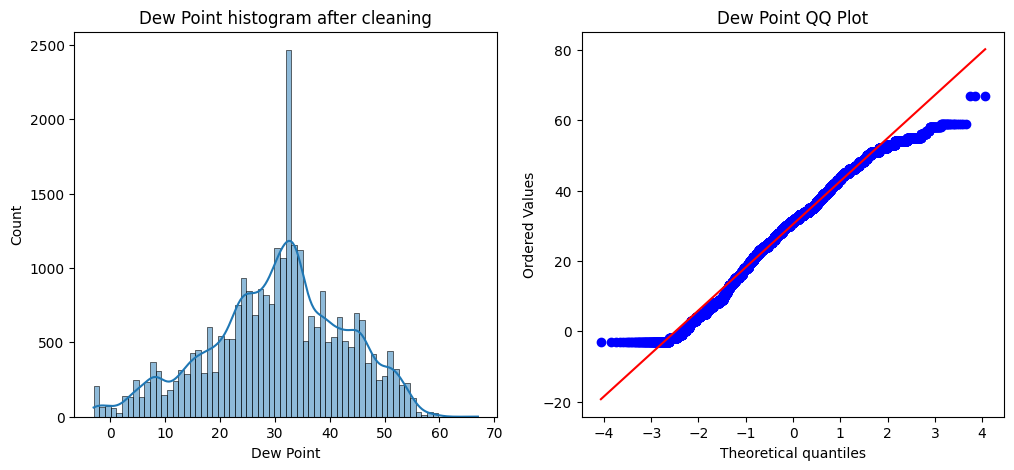

In [17]:
from scipy import stats

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Dew Point'], kde=True)
plt.title("Dew Point histogram after cleaning")

plt.subplot(1, 2, 2)
stats.probplot(df['Dew Point'], dist='norm', plot=plt)
plt.title("Dew Point QQ Plot")

plt.show()

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28818 entries, 0 to 28819
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28818 non-null  int64  
 1   DAY_OF_MONTH       28818 non-null  int64  
 2   DAY_OF_WEEK        28818 non-null  int64  
 3   OP_UNIQUE_CARRIER  28818 non-null  object 
 4   DEST               28818 non-null  object 
 5   DEP_DELAY          28818 non-null  int64  
 6   CRS_ELAPSED_TIME   28818 non-null  int64  
 7   DISTANCE           28818 non-null  int64  
 8   CRS_DEP_M          28818 non-null  int64  
 9   CRS_ARR_M          28818 non-null  int64  
 10  Temperature        28818 non-null  int64  
 11  Dew Point          28818 non-null  int64  
 12  Humidity           28818 non-null  int64  
 13  Wind               28818 non-null  object 
 14  Wind Speed         28818 non-null  int64  
 15  Wind Gust          28818 non-null  int64  
 16  Pressure           28818 no